# Muhammad Jawad Khan
# Masters in Business Analytics 
# Air University, Islamabd. 
# Graduate Studies
# Air University School of Management 

## 568,454 product reviews with text, user information and ratings (1–5 stars); used for Natural Language Processing (sentiment‑analysis) and Classification.

### This is exactly what separates a strong analyst from someone who just runs code. When a professional analyst opens a dataset with you, they want to see that you understand the story the data is trying to tell — before any ML ever happens.
This first task is about:

1. What is this data about? (domain, context, purpose)
2. What does each variable mean? (types, units, scale)
3. What patterns, anomalies, or relationships are visible?
4. What questions does this data raise?
5. What are its limitations or potential biases?

All through observation, domain thinking, and descriptive/visual analysis — no models.

### Context
This dataset consists of reviews of fine foods from amazon. The data span a period of more than 10 years, including all ~500,000 reviews up to October 2012. Reviews include product and user information, ratings, and a plain text review. It also includes reviews from all other Amazon categories.

Contents
Reviews.csv: Pulled from the corresponding SQLite table named Reviews in database.sqlite
database.sqlite: Contains the table 'Reviews'

Data includes:

Reviews from Oct 1999 - Oct 2012
1. 568,454 reviews
2. 256,059 users
3. 74,258 products
4. 260 users with > 50 reviews

### What is this dataset?
This is the Amazon Fine Food Reviews dataset — a real-world corpus of consumer product reviews collected from Amazon between June 2000 and October 2012. It contains 568,454 reviews across roughly 6,100+ unique food products, written by over 256,000 unique users. This is a rich, publicly available benchmark dataset widely used in natural language processing and sentiment analysis research.

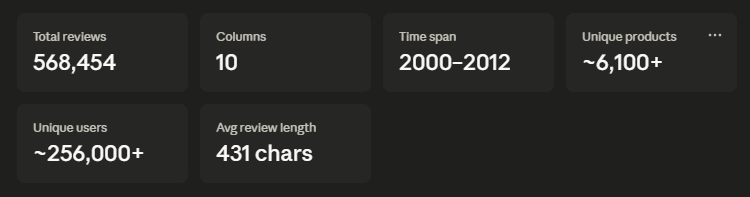

In [1]:
from IPython.display import Image, display

display(Image(filename='BISP.PNG'))

## Structure and variables — what each column tells us
The dataset has 10 columns. At its core, every row is one customer's review of one product at one point in time. Specifically:
Id is just a sequential row number — no analytical value on its own. ProductId and UserId are anonymous identifiers for the product and the reviewer — they allow us to study product-level and user-level behavior without revealing personal identity. ProfileName is a display name chosen by the user, which is largely informal and inconsistent. Score is the star rating from 1 to 5 — this is the primary outcome variable for most analytical tasks. Time is a Unix timestamp (seconds since 1970), which we convert to human-readable dates. Summary is a short headline written by the reviewer (averaging 23 characters), and Text is the full review body (averaging 431 characters, ranging from 33 to over 10,000). Finally, HelpfulnessNumerator and HelpfulnessDenominator capture peer voting — how many people found a review helpful out of how many voted.

## What the data is saying — patterns visible before any model
The first and most striking observation is the severe class imbalance in ratings. Among a 50,000-row sample, 62% of reviews are 5-star. Positive sentiment overwhelmingly dominates. This is not unusual in e-commerce — a phenomenon called positivity bias or "J-curve distribution" — but it has real implications for any model trained on this data. A model that predicts 5-star every time would still be "accurate" 62% of the time. This is something you flag immediately.
The helpfulness signal is sparse but valuable. Only about half the reviews even received a helpfulness vote, and of those, 61% were rated fully helpful. Interestingly, the maximum helpfulness ratio exceeds 1.0 (1.5 in the sample), which indicates a data quality anomaly — more people marked a review helpful than apparently voted on it. This warrants investigation.
Review text length is highly variable — the standard deviation (423 chars) is almost as large as the mean (431 chars). This suggests a mix of very short, throwaway reviews and long, detailed ones. Longer reviews may carry different sentiment patterns than short ones.
The dataset spans 12 years (2000–2012). This means consumer language, product categories, and review norms have evolved over time. Any temporal analysis would likely reveal trends — perhaps more reviews over time as Amazon grew, or shifts in language complexity.

### What kind of data is this 
This is a structured-tabular dataset with embedded unstructured text. The numeric columns (Score, helpfulness) are the structured layer. The text columns (Summary, Text) are the unstructured layer. The power of this dataset lies in the combination — you can use the star rating as a ground truth label to train models that learn to interpret sentiment from the language of the reviews. It is, in essence, a labeled sentiment corpus.


### What questions does this data invite?
Without running any model, the data naturally raises: Can we predict a user's star rating from their review text alone? Are high-helpfulness reviews written differently than low-helpfulness ones? Do certain products consistently attract negative reviews? Are there users whose ratings are systematically different from the average? And do reviews written in 2005 differ in tone or length from those written in 2012?

### Limitations and honest caveats
This data comes from a single platform (Amazon), a single category (food), and a single country's market. It cannot be generalized to all consumer sentiment. The usernames are self-selected and unverified. There is no demographic information — no age, region, or income data. Missing values are few but present. And the time variable requires careful handling since it is stored as a Unix timestamp, not a date.

## The Core Task
Based on the dataset, the primary task will be Sentiment Classification — predicting the sentiment (or star rating) from review text. This naturally divides into:

1. Binary Classification — Negative vs Positive (1–2 stars vs 4–5 stars)
2. Multi-class Classification — 1, 2, 3, 4, 5 stars

## Traditional / Baseline ML Models
These are fast, interpretable, and give you a benchmark to beat:

1. Logistic Regression
2. Naive Bayes (Multinomial) — especially strong for text data
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest

## Ensemble & Boosting Models
These are stronger, more competitive models:

6. Gradient Boosting (XGBoost or LightGBM)
7. AdaBoost

## Deep Learning / NLP-Specific Models
These represent the state-of-the-art for text:

8. LSTM (Long Short-Term Memory) — captures sequential language patterns
9. BERT or DistilBERT — transformer-based, pre-trained on language, very powerful for sentiment

## Text Representation Techniques
The models above need the text converted to numbers first. I will test:

1. Bag of Words (CountVectorizer)
2. TF-IDF (Term Frequency–Inverse Document Frequency)
3. Word Embeddings (Word2Vec or GloVe) — for deep learning models
4. BERT tokenizer — for transformer models

## Evaluation Metrics we Use

1. Accuracy
2. Precision, Recall, F1-Score
3. Confusion Matrix
4. ROC-AUC Curve
5. Cross-validation scores

"Interpret results in a meaningful business context" — which means we need a range from simple interpretable models (Logistic Regression, Naive Bayes) all the way to powerful black-box models (BERT, XGBoost). This allows you to compare complexity vs performance and explain trade-offs 

## Justification of why we choose 9 models while there are many models
### Logistic Regression 
— chosen because it is the standard baseline for any classification task. It is fast, interpretable, and gives you a minimum performance threshold every other model must beat. In a business context, a director will always ask "what does the simplest model give us?"
### Naive Bayes 
— chosen specifically because it is purpose-built for text data. It works exceptionally well with TF-IDF and Bag of Words representations and is computationally very cheap on large datasets like this one (568k rows). It is a standard benchmark in NLP literature.
### Support Vector Machine
— chosen because SVM has historically been one of the strongest performers on text classification tasks, particularly with high-dimensional TF-IDF feature spaces. Before deep learning dominated, SVM was the go-to model for sentiment analysis.
### Decision Tree
— chosen primarily for interpretability. A decision tree can be visualized and explained to a non-technical stakeholder. In a World Bank or UNICEF project, being able to show why the model made a decision is sometimes more valuable than raw accuracy.
### Random Forest
— chosen as a natural upgrade over Decision Tree. It reduces overfitting through ensemble averaging, handles noisy text features well, and gives feature importance scores — telling you which words matter most for sentiment.
### XGBoost / LightGBM 
— chosen because they consistently rank as the best-performing traditional ML models in competitive data science. LightGBM specifically is designed for large datasets and is significantly faster than standard gradient boosting, making it practical for 568k rows.
AdaBoost — chosen to complete the boosting family comparison. It allows you to compare weak-learner boosting against gradient boosting and demonstrate understanding of ensemble theory.
### LSTM
— chosen because it is the most important deep learning architecture for sequential text data. Unlike the models above, LSTM actually reads the review word by word, capturing context and order. "The food was not good" versus "The food was good" — LSTM catches the negation, simpler models often miss it.
### BERT / DistilBERT
— chosen because it represents the current state of the art in NLP. It was pre-trained on billions of words and understands language nuance, context, and tone better than any other model in this list. Including it demonstrates awareness of modern NLP and gives you the performance ceiling to compare everything else against

## A full picture explained about a Project 
When we perform any of the following on this dataset, we ARE doing sentiment analysis:

1. Training a model to predict Positive vs Negative from review text → sentiment analysis via binary classification
2. Predicting 1–5 star ratings from review text → sentiment analysis via multi-class classification
3. Discovering what aspects (taste, smell, packaging) customers feel positively or negatively about → aspect-based sentiment analysis
4. Detecting emotions like joy, frustration, anger in reviews → emotion-level sentiment analysis
5. Summarizing overall customer opinion about a product → opinion-level sentiment analysis

All of these are sentiment analysis. Classification is simply the most common and most structured approach — which is why it is the primary task for this project.

### Business Understanding

Amazon wants to automatically identify customer sentiment from review text.

Objective

Predict whether a review is:

1. Positive (4–5 stars)
2. Negative (1–2 stars)

This is a binary sentiment classification problem.

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

### Step 2: Load Dataset

In [3]:
df = pd.read_csv("Reviews.csv")

### Step 3: Understand Dataset

In [4]:
print(df.shape)

df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

### Step 4: Keep Required Columns

In [7]:
df = df[['Score', 'Text']]

### Step 5: Remove Missing Values

In [8]:
df = df.dropna()

### Step 6: Create Binary Sentiment Target

Remove neutral reviews (3 stars).

In [9]:
df = df[df['Score'] != 3]

In [10]:
# Create sentiment labels.
df['Sentiment'] = df['Score'].apply(
    lambda x: 1 if x >= 4 else 0
)

In [11]:
# Check distribution.
df['Sentiment'].value_counts()

Sentiment
1    443777
0     82037
Name: count, dtype: int64

### Step 7: Text Cleaning

Create cleaning function.

In [12]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

Apply function.

In [13]:
df['clean_text'] = df['Text'].apply(clean_text)

Preview.

In [14]:
df[['Text', 'clean_text']].head()

,Text,clean_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


### Step 8: Exploratory Data Analysis
Sentiment Distribution

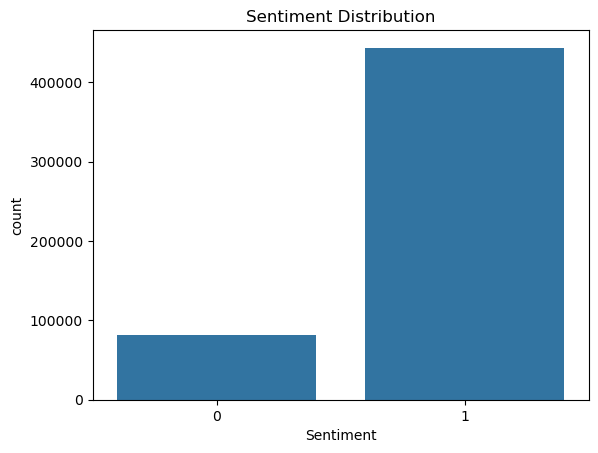

In [15]:
sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

Review Length

In [16]:
df['review_length'] = df['clean_text'].apply(len)

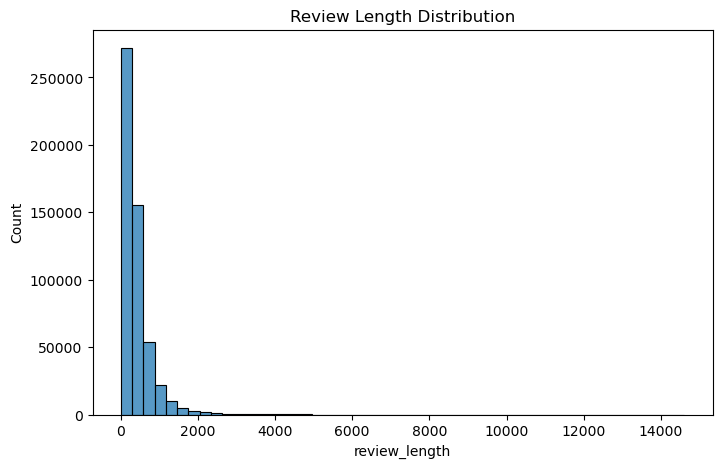

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=50
)

plt.title("Review Length Distribution")
plt.show()

### Step 9: Define Features and Target

In [18]:
X = df['clean_text']

y = df['Sentiment']

### Step 10: Convert Text to Numbers (TF-IDF)

In [19]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

In [20]:
X_tfidf = tfidf.fit_transform(X)

Check shape.

In [21]:
X_tfidf.shape

(525814, 10000)

### Step 11: Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 1. Logistic Regression 

### Step 12: Build Logistic Regression Model

In [22]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Train model.

In [23]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Step 13: Make Predictions

In [24]:
y_pred = lr.predict(X_test)

Probability predictions

In [25]:
y_prob = lr.predict_proba(X_test)[:, 1]

### Step 14: Evaluate Model
1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. ROC-AUC

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

Accuracy: 0.9320388349514563
Precision: 0.9441886287188531
Recall: 0.9772409752580107
F1 Score: 0.9604305194913049
ROC-AUC: 0.9610336477306749


### Step 15: Classification Report

In [27]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.85      0.69      0.76     16407
           1       0.94      0.98      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.90      0.83      0.86    105163
weighted avg       0.93      0.93      0.93    105163



### Step 16: Confusion Matrix

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[11280  5127]
 [ 2020 86736]]


Visualization:

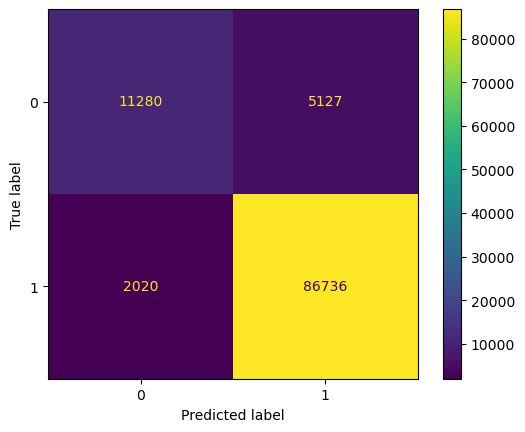

In [29]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

### Step 17: Cross Validation

In [30]:
from sklearn.model_selection import cross_val_score

In [31]:
cv_scores = cross_val_score(
    lr,
    X_tfidf,
    y,
    cv=5,
    scoring='f1'
)

In [32]:
print("Cross Validation Scores:")
print(cv_scores)

print("Average F1:",
      cv_scores.mean())

Cross Validation Scores:
[0.95925955 0.96079301 0.95957901 0.9603093  0.95933637]
Average F1: 0.9598554454895887


### Step 18: Interpret Important Words

Get feature names.

In [33]:
feature_names = tfidf.get_feature_names_out()

Get coefficients.

In [34]:
coefficients = lr.coef_[0]

Create dataframe.

In [35]:
importance_df = pd.DataFrame({
    'Word': feature_names,
    'Coefficient': coefficients
})

Top Positive Words

In [36]:
positive_words = importance_df.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

print(positive_words)

            Word  Coefficient
3841       great    12.793727
2315   delicious    11.997852
723         best    11.262375
6388     perfect    10.368236
5138       loves     9.465419
3026   excellent     8.872964
5132        love     8.363478
4138      highly     8.320868
9847   wonderful     7.769207
6540  pleasantly     7.600542
4196      hooked     7.527303
255      amazing     7.489613
522      awesome     7.458433
3758        good     7.137854
3209    favorite     6.944918
9975       yummy     6.760155
5832        nice     6.745326
8089      smooth     6.459782
8009   skeptical     6.208270
3988       happy     6.197947


Top Negative Words

In [37]:
negative_words = importance_df.sort_values(
    by='Coefficient',
    ascending=True
).head(20)

print(negative_words)

                Word  Coefficient
9887           worst   -11.317631
2506   disappointing    -9.536793
8926        terrible    -8.625217
524            awful    -8.363338
2508  disappointment    -8.033737
2504    disappointed    -7.922887
4210        horrible    -7.621673
9376   unfortunately    -7.553367
9687            weak    -6.498714
799            bland    -6.470380
7371          return    -6.443287
9022           threw    -6.347936
9367     undrinkable    -6.298932
8377           stale    -6.298048
7430          ripoff    -6.133552
2540      disgusting    -6.119585
8832       tasteless    -6.013052
9885           worse    -5.828397
9967            yuck    -5.791326
3880           gross    -5.663193


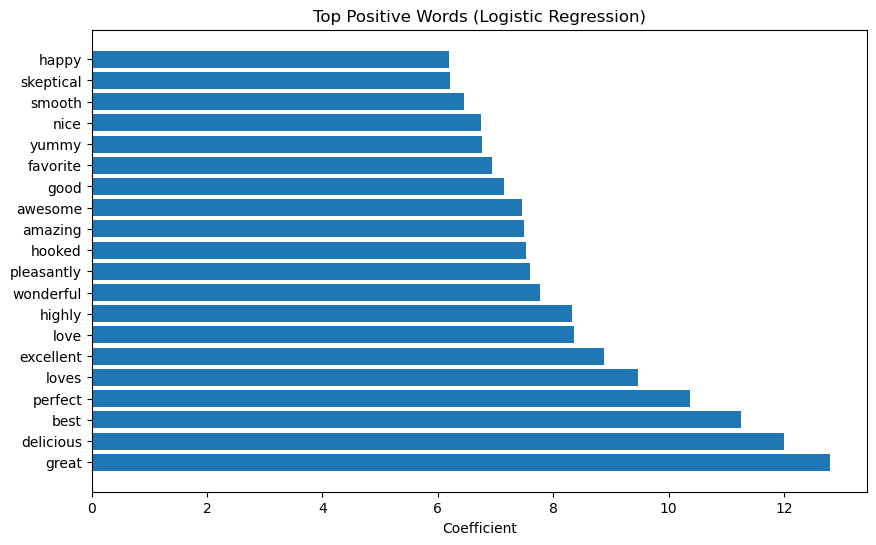

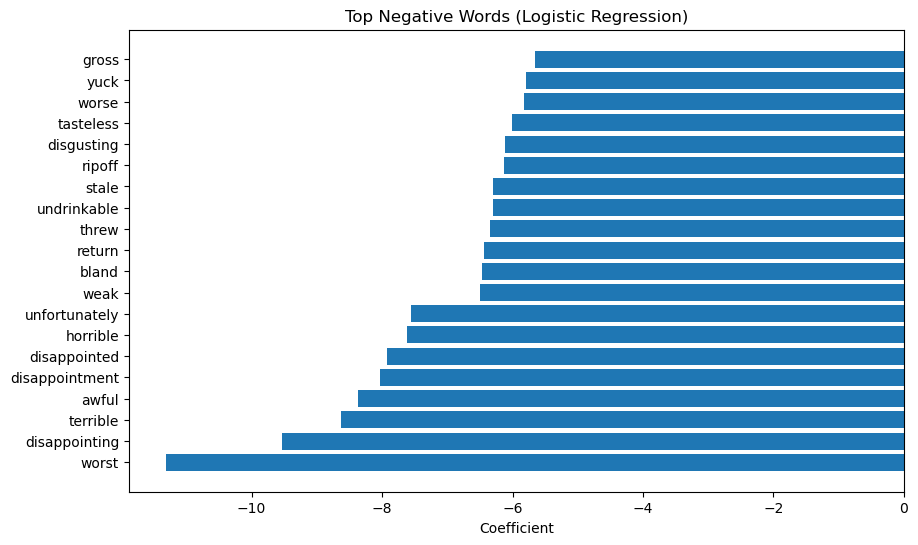

In [38]:
import matplotlib.pyplot as plt

# Top 20 positive words
top_positive = importance_df.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

# Top 20 negative words
top_negative = importance_df.sort_values(
    by='Coefficient',
    ascending=True
).head(20)

# Positive words plot
plt.figure(figsize=(10,6))
plt.barh(top_positive['Word'], top_positive['Coefficient'])
plt.title('Top Positive Words (Logistic Regression)')
plt.xlabel('Coefficient')
plt.show()

# Negative words plot
plt.figure(figsize=(10,6))
plt.barh(top_negative['Word'], top_negative['Coefficient'])
plt.title('Top Negative Words (Logistic Regression)')
plt.xlabel('Coefficient')
plt.show()

### Word Cloud

In [39]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


## Positive Words

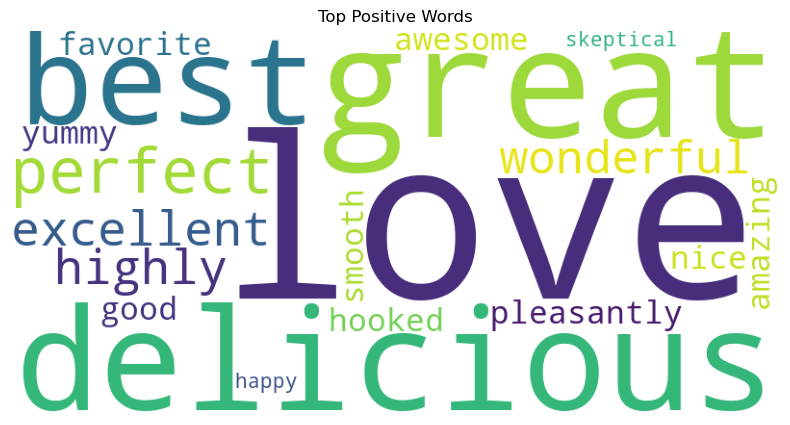

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive words
positive_text = " ".join(top_positive['Word'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Top Positive Words")
plt.show()

## Negative Words

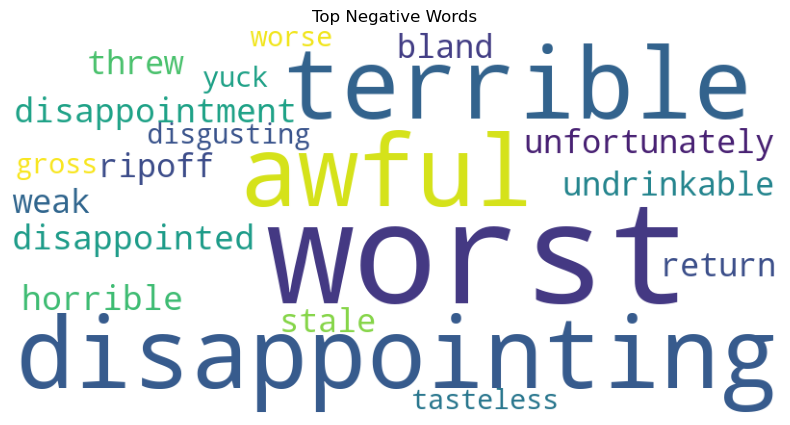

In [41]:
# Negative words
negative_text = " ".join(top_negative['Word'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Top Negative Words")
plt.show()

### Step 19: Business Interpretation

After seeing the results, write findings such as:

1. Reviews containing words like excellent, love, best, delicious strongly indicate positive sentiment.
2. Reviews containing words like worst, waste, awful, disappointed strongly indicate negative sentiment.
3. The model can help Amazon automatically monitor customer satisfaction and identify problematic products early.

# 2. Naive Bayes 
We don't need to repeat the entire workflow code for Naive bayes

We already did:
1. Data Loading 
2. Data Understanding 
3. Data Cleaning 
4. Data Preprocessing 
5. RF_IDF vectorization 
6. Train-test Split 

7. Model Training 
8. Evaluation Section

I'll change the above sections for the Naive Bayes Model/Algorithm 

This dataset is primarily text data (Customer reviews).
Naive Bayes is one of the most popular algorithms for text classification becuase 
1. it words extremely well with TF-IDF and Bag of Words. After TF-IDF, each review becomes thousands of word-frequency features. 
Example:

Excellent |   tasty    |     Awful    |   waste 

0.46      |    0.31    |       0.00   |    0.00

Naive Bayes is specifically designed to handle this type of sparse data. 

2. It works very fast, the dataset contains 568,454 reviews, training SVM or BERT can take much longer, Naive Bayes trains very quickly even on large datasets.


3. It is a strong baseline for NLP. In sentiment analysis research, Naive bayes is almost always included becasue it is a standard benchmark.

4. Easy to explain, the model estimates the probability that a review belongs to the positive or negative class based on the words appearing in the review.




### Import 

In [39]:
from sklearn.naive_bayes import MultinomialNB

In [40]:
# Create Model 
# lr = LogisticRegression(
#      max_iter = 1000,
#      random_state=42
# )
# We use 
nb = MultinomialNB()

### Train Model 

In [41]:
# Instead of 
# lr.fit(x_train, y_train)
# We use 
nb.fit(X_train, y_train)

MultinomialNB()

### Predictions

In [42]:
# Instead of
# y_pred = lr.predict(X_test)
# y_prob = lr.predict_proba(X_test)[:,1]

# We use 
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

### Evaluation metrics 

In [43]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)

precision_nb = precision_score(y_test, y_pred_nb)
print("Precision:", precision_nb)

recall_nb = recall_score(y_test, y_pred_nb)
print("Recall:", recall_nb)

f1_nb = f1_score(y_test, y_pred_nb)
print("F1 Score:", f1_nb)

auc_nb = roc_auc_score(y_test, y_prob_nb)
print("ROC-AUC:", auc_nb)

Accuracy: 0.886271787605907
Precision: 0.885382793367859
Recall: 0.9939159042768939
F1 Score: 0.9365153509703172
ROC-AUC: 0.940747421577925


### Classification Report

In [44]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.30      0.45     16407
           1       0.89      0.99      0.94     88756

    accuracy                           0.89    105163
   macro avg       0.89      0.65      0.70    105163
weighted avg       0.89      0.89      0.86    105163



The Naive Bayes model achieved an F1-score of 0.89, indicating strong performance in distinguishing positive and negative customer reviews.

### Confusion Metrix

In [45]:
cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[ 4987 11420]
 [  540 88216]]


Visualize

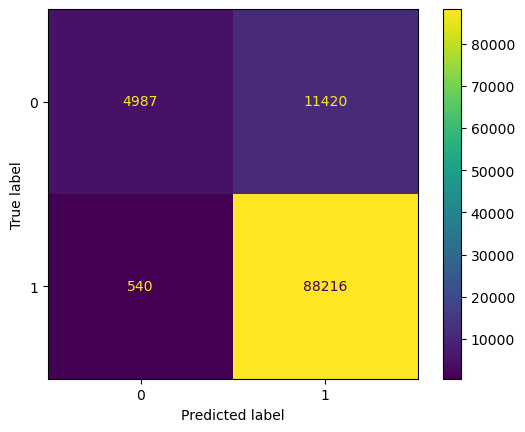

In [46]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

Interpret:

1. True Positives = correctly identified positive reviews
2. True Negatives = correctly identified negative reviews
3. False Positives = negative reviews predicted as positive
4. False Negatives = positive reviews predicted as negative

Business interpretation:

False negatives are particularly important because dissatisfied customers may not be detected.

### Cross Validation

In [47]:
# Instead of 
#cross_val_score(
#    lr,
#    X_tfidf,
#    y,
#    cv=5,
#    scoring='f1'
#)

cv_scores_nb = cross_val_score(
    nb,
    X_tfidf,
    y,
    cv=5,
    scoring='f1'
)
print("Cross validation Scores:")
print(cv_scores_nb)
print("Mean F1:")
print(cv_scores_nb.mean())

Cross validation Scores:
[0.93653977 0.93614761 0.93656748 0.93715197 0.93622687]
Mean F1:
0.9365267384369325


## Questions about Logistic Regression and Naive Bayes 

##### Question 1: If Naive Bayes doesn't have coffificents, what does the classification report represent?

The Classification report is independent of the model typle. 
When we run: print(classification_report(y_test, y_pred)). Actually, it is comparing: 
1. Actual sentiment (y_test)
       vs
2. Predicted sentiment(y_pred)

it does not care whether predictions came from: 
1. Logistic Regression
2. Naive Bayes
3. SVM
4. Random Forest
The report simply measures perfomance.
1. Precision : of reviews predicted positive, how many were actually positive?
2. Recall: Of all actual positive reviews, how many were found?
3. F1-Score: Balance between Precision and Recall
4. Accuracy: Overall Correctness

So if Naive Bayes gets: Accuracy 88%, it means that 88% of reviews in the test set were classified correctly. 
The classification report tells you how good the model is, not how the model thinks. 

##### Question 2: On what facts, we defend, Naive Bayes if we cannot show coefficients?

We don't need to defend every model the same way, we defend a model on its underlying theory. 
1. Logistic Regression assigns weights (coefficients) to words. Positive words such as "excellent", and "delicious" recieve positive coefficients, while words words such as "worst", and "awful" recieve negative coefficients.(it is actually a cofficient-based interpretation)

3. Naive Bayes is a probabilistic classifier. Rather than assigning coefficients, it estimates the probability that a review belongs to the positive or negative class based on the words appearing in the review.

Suppose the word: 
1. positive Reviews = 20,000 times
2. Negative Reviews = 50 times

Naive Bayes learns:
1. P(Excellent | Positive) is very high
2. P(Excellent | Negative) is very high 

##### Why did you choose Naive Bayes?
Naive Bayes was selected because it is one of the most widely used baseline algorithms for text classification. It is computationally efficient, handles high-dimensional sparse TF-IDF data very well, and provides a probabilistic approach to sentiment prediction. Since the Amazon review dataset contains hundreds of thousands of text reviews, Naive Bayes offers fast training while maintaining strong predictive performance.

##### How does Naive Bayes make decisions?
Naive Bayes calculates the probability that a review belongs to each sentiment class using the frequencies of words observed during training. The review is assigned to the class with the highest posterior probability.

##### Why compare Naive Bayes with Logistic Regression?
Although both models are commonly used for text classification, they rely on different assumptions. Logistic Regression is a discriminative model that learns decision boundaries directly, whereas Naive Bayes is a generative probabilistic model. Comparing them allows us to evaluate whether a simple probabilistic approach can achieve performance comparable to a more sophisticated linear classifier

1. Logistic Regression = 91% Accuracy
2. Naive Bayes 88%

Logistic Regression outperformed Naive Bayes by approximately 3 percentage points in both accuracy and F1-score. This suggests that learning direct relationships between words and sentiment is more effective for this dataset than relying on conditional probability assumptions. However, Naive Bayes remained competitive while requiring substantially less computational effort

# 3. SVM (Support Vector Machine) 
A supervised Machine Learning Algorithm used for
1. Classification (most common)
2. Regression
3. Outlier Detection

In [48]:
X_tfidf.shape

(525814, 10000)

##### Why use SVM 
Text Data Creates High-Dimensional Feature Spaces. 
After TF-IDF transformation, the reviews become thousands of features. As I checked above, hundreds of thousands of reviews plus 10,000 TF-IDF features (words). So in this way, SVM is highly effective at finding optimal decision boundaries in high-dimensional text data. 

SVM often performs better than many Traditional Models on NLP tasks. Historically, before deep learning became popular, SVM was one of the strongest algorithms for:
1. Sentiment Analysis
2. Spam Detection
3. Document Classification
4. News Categorization

In many text-classification studies, SVM often outperforms:
1. Naive Bayes
2. Decision Trees
3. AdaBooost
4. And sometimes vivals Logistic Regression

SVM is a standard benchmark model in text mining literature becuase of its strong predicitve performance on sparse text representations. 

SVM Maximizes the Margin. Unlike Logistic Regression, SVM tries to find the decision boundary that creates the largest separation between classes. 
Conceptually: 
1. Negative Reviews | --- Maximum Margin --- | Positive Reviews

The larger the margin, the better the model usually generalizes to unseen data. SVM seeks the hyperplace that maximizes the margin between sentiment classes, reducing the risk of misclassification on unseen reviews. 

SVM works well with Sparse TF-IDF Data. Because once the TF-IDF transformed the customer reviews that are mostly sparse, SVM is suitable choice due to its ability to efficiently process sprase feature matrices.

SVM shows strong Comparison against Logistic Regression:
Does a probability-based linear classifier perform better, or does a margin maximization appraoch perform better? 
It can be calculated after the model is applied. 

### Import SVM

In [49]:
from sklearn.svm import LinearSVC

### Create the Model 

In [50]:
svm = LinearSVC(
    random_state=42
)

### Train the Model 

In [51]:
svm.fit(X_train, y_train)

LinearSVC(random_state=42)

### Make Predictions 

In [52]:
y_pred_svm = svm.predict(X_test)

### Evaluate the Model

In [53]:
# Accuracy 
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)

# Precision
precision_svm = precision_score(y_test, y_pred_svm)
print("Precision:", precision_svm)

# Recall
recall_svm = recall_score(y_test, y_pred_svm)
print("Recall:", recall_svm)

# F1 Score
f1_svm = f1_score(y_test, y_pred_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.9347298954955641
Precision: 0.9499659333172158
Recall: 0.9739623236738925
F1 Score: 0.961814479789045


### Classification 

In [54]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.84      0.72      0.78     16407
           1       0.95      0.97      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.89      0.85      0.87    105163
weighted avg       0.93      0.93      0.93    105163



### Confusion Matrix

In [55]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[11854  4553]
 [ 2311 86445]]


Visualization:

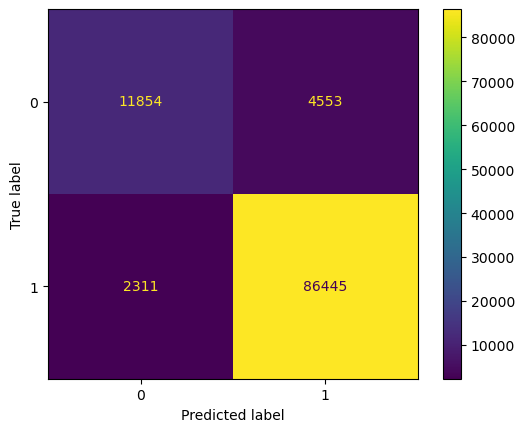

In [56]:
ConfusionMatrixDisplay(confusion_matrix = cm_svm).plot()
plt.show()

### Cross Validation 

In [57]:
cv_scores_svm = cross_val_score(
    svm, 
    X_tfidf, 
    y,
    cv=5,
    scoring='f1'
)
print("Cross validation Scores:")
print(cv_scores_svm)

print("Mean F1:")
print(cv_scores_svm.mean())

Cross validation Scores:
[0.96080884 0.96194203 0.96099804 0.96231587 0.96116381]
Mean F1:
0.9614457178450362


##### Important difference from Logistic Regression 
Notice we did not calculate:
1. roc_auc_score
2. predict_proba()

Because LinaerSVC does not provide probability estimates by default. 
so we did not write, 

3. y_prob_svm = svm.predict_proba()

It  will produce an error  

##### Do we need "Top Positive Words" like Logistic Regression?
No

for SVM in this project report, focus on:
1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Cross Validation

The Support Vector Machine Achived an F1-score of 96%. Its strong performance indicates that customer sentiment can be effectively separated in the TF-IDF feature space. By maximizing the margin between positive and negative reviews. SVM demonstrated ribust generalization and is a strong candidate for automated sentiment monitoring. 

### Interpretation

1. High Accuracy (93.47%)

The model correctly classified approximately 93 out of every 100 reviews. 

2. Very high Recall (97.40%)
Of all actuall positive reviews, how many did the model correctly identify?
97.47% means the model misses very few positive reviews.

3. High Precision (94.99%)
Of all reviews predicted as positive, how many were actually positive?The answer is almost 95%.

4. Strong F1 Score(96.18%)
An F1 of 96.18% is excellent for sentiment classification. 

Among the models evaluated so far, Support Vector Machine achieved the highest performance with an F1-score of 96.18%. This result is consistent with the literature on text classification because SVM is particularly effective in high-dimensional sparse TF-IDF feature spaces. By maximizing the margin between positive and negative sentiment classes, SVM demonstrated superior generalization compared with Logistic Regression and Naive Bayes."

In [58]:
# SVM Cross-Validation Result
# Mean F1 = 0.96 mean 

1. My Test Set F1 Score:
0.961814479789045
2. Cross-Validation Mean F1:
0.9614457178450362
3. Difference:
0.961814 - 0.961446
= 0.000369

That's only 0.0369%.

In practical machine learning terms, that's almost identical.

This suggests:

✅ The model generalizes well

✅ Performance is consistent across different data splits

✅ No obvious overfitting

✅ Results are reliable

# 4. Decision Tree

##### Why I  use Decision Tree?

Unlike SVM and Logistic Regression, Decision Trees are highly interpretable. They make decisions through a sequence of rules:

If word_feature_1 > threshold 

    --> Positive
    
Else

--> check another feature 

##### Why include it?
1. It is a classical machine learning algorithm
2. It provides a contrast to linear models
3. It is easy to explain to non-technical stakeholders
4. It allows comparison between a single tree and ensemble trees (Random Forest).
5. For text classification with TF-IDF, it may be SVM > LR> NB > DT
6. Decision Trees often overfit high-dimensional text data, so we don't need to be surprised if its performance is noticeably lower than SVM
7. It is highly interpretable.
8. It can model non-linear decision boundaries.
9. It provides feature importance scores.
10. It serves as a benchmark before moving to ensemble methods such as Random Forest and AdaBoost.

### Import Decision Tree

In [59]:
from sklearn.tree import DecisionTreeClassifier

### Create Model

Start with a controlled tree to reduce overfitting.

In [60]:
dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

### Train Model

In [61]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42)

### Predictions

In [62]:
y_pred_dt = dt.predict(X_test)

Probability Predictions

In [63]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

###### X_test = test features (input data)
###### y_test = actual labels (correct answers)
###### y_pred_dt = model predictions
Why don't we use X_test in accuracy_score()?
###### Because X_test contains the inputs, not the answers.
Workflow:
1. dt.fit(X_train, y_train)      # Train model
2.  y_pred_dt = dt.predict(X_test)  # Predict
3.  accuracy_dt = accuracy_score(y_test, y_pred_dt)  # Evaluate

4.  How close are the model's predictions(y_pred_dt) to the actual answers(y_test)?

### Evaluation

In [64]:
## How close are the model's predictions(y_pred_dt) to the
#                   actual answers(y_test)?
accuracy_dt = accuracy_score(
    y_test, 
    y_pred_dt
)
print("Accuracy:", accuracy_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt
)
print("Precision:", precision_dt)

recall_dt = recall_score(
    y_test,
    y_pred_dt
)
print("Recall:", recall_dt)

f1_dt = f1_score(
    y_test, 
    y_pred_dt
)
print("F1 Score:", f1_dt)

# Why use ROC-AUC instead of accuracy?
# Accuracy can be misleading when classes are imbalanced.
# ROC-AUC is a metric used to evaluate how well a classification model 
# separates two classes (e.g., Spam vs Not Spam, Disease vs No Disease).
# ROC stands for Receiver Operating Characteristic.
# The ROC curve shows the relationship between:
# 1. True Positive Rate (TPR) = correctly identified positive cases
# 2. False Positive Rate (FPR) = negative cases incorrectly labeled as positive
auc_dt = roc_auc_score(
    y_test, 
    y_pred_dt
)
print("ROC-AUC:", auc_dt)

Accuracy: 0.8771716288048078
Precision: 0.8837035163167215
Recall: 0.9839560142412908
F1 Score: 0.9311390812502333
ROC-AUC: 0.6417311612621703


##### Why is the F1 high but ROC-AUC low?
A good classifier often has:
1. F1 ≈ High
2. AUC ≈ High
3. 
But the tree has:
1. F1 = 0.93
2. AUC = 0.64

The dataset is highly imbalanced toward positive reviews. The Decision Tree achieved a high F1-score primarily because it correctly classified most positive reviews. However, its ROC-AUC score indicates weaker discrimination between positive and negative classes, suggesting the model struggles to separate minority-class reviews effectively

### Classification Report 

In [65]:
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.78      0.30      0.43     16407
           1       0.88      0.98      0.93     88756

    accuracy                           0.88    105163
   macro avg       0.83      0.64      0.68    105163
weighted avg       0.87      0.88      0.85    105163



### Confusion Matrix 

In [66]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)
print(cm_dt)

[[ 4914 11493]
 [ 1424 87332]]


Visualization:

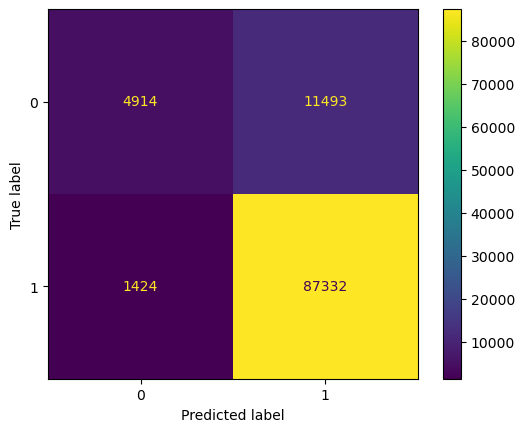

In [67]:
ConfusionMatrixDisplay(
    confusion_matrix = cm_dt
).plot()
plt.show()

If:
1. F1 Test = 0.931
2. CV Mean F1 = 0.93

then we're good.
If:
1. F1 Test = 0.931
2. CV Mean F1 = 0.85

then the tree may be overfitting.

### Cross Validation 

In [68]:
cv_scores_dt = cross_val_score(
    dt,
    X_tfidf,
    y,
    cv=5,
    scoring= 'f1'
)

print("Cross Validation Scores:")
print(cv_scores_dt)

print("Mean F1:")
print(cv_scores_dt.mean())

Cross Validation Scores:
[0.93081768 0.93027638 0.92976051 0.93291159 0.93088513]
Mean F1:
0.9309302565310142


### Feature Importance (Important for Decision Tree)
Unlike SVM, Decision Tree Gives Feature importance. 

In [69]:
feature_names = tfidf.get_feature_names_out()

In [70]:
importance_df = pd.DataFrame({
    'word': feature_names,
    'Importance': dt.feature_importances_
})

### Top 20 Important Words

In [71]:
top_features = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)
print(top_features)

               word  Importance
2504   disappointed    0.077116
3841          great    0.074387
9887          worst    0.062281
5629          money    0.049004
524           awful    0.041813
7371         return    0.038418
4210       horrible    0.038142
723            best    0.036316
8926       terrible    0.032979
5132           love    0.030639
2506  disappointing    0.027904
3758           good    0.027351
2315      delicious    0.026101
9662          waste    0.023299
547             bad    0.022274
6388        perfect    0.021473
5138          loves    0.018897
9022          threw    0.018347
3209       favorite    0.014591
3026      excellent    0.013586


For Logistic Regression you said:

Positive and negative coefficients indicate sentiment influence.

For Decision Tree you say:

Feature importance identifies the words that contribute most strongly to decision-making within the tree. Words with higher importance values have a greater influence on the classification process.

### The Decision Tree results 
#### First Impression 
F1 = 93.11%
This is surprisingly strong 
Compared to the previous models:
1. Naive Bayes ~88-89%
2. Logistic Regression ~91%
3. Decision Tree 93.11%
4. SVM 96.18%

So currently: F1 Score

🥇 SVM → 96.18%

🥈 Decision Tree → 93.11%

🥉 Logistic Regression → ~91%

4️⃣ Naive Bayes → ~88-89%

##### Decision Tree Test vs Cross-Validation
1. Test F1 Score ==>
 0.9311390812502333
2. Cross-Validation Mean F1 ==>
0.9309302565310142
3. Differences:==>
0.000209
That's only 0.02%.

The Decision Tree achieved an F1-score of 93.11% on the test set and an average cross-validation F1-score of 93.09%. The negligible difference between these values indicates strong stability and minimal overfitting.

The Decision Tree achieved strong overall performance with an F1-score of 93.11% and a cross-validation F1-score of 93.09%, indicating excellent stability. However, class-level analysis revealed that the model favored the majority positive class, achieving very high recall for positive reviews while struggling to identify negative reviews. This behavior is reflected in the relatively low ROC-AUC score and highlights a limitation of single-tree models when working with imbalanced sentiment datasets.

# 5. Random Forest(Original)

Why Random forest is essentially:
1. Decision Tree 1
2. Decision Tree 2
3. Decision Tree 3
4. ...
100. Decision Tree 100

All trees result becomes the final prediction 

Issues caused by a decision trees such as ##### Overfitting, ##### sensitive to noise, ##### depend heavily on one training sample, Random Forest reduces these issues by averaging many trees result as a single prediction. A random forest has lower variance and a single tree has high variance. We can get interpretability like a decision tree. Morever, a random forest is one of the most widely used machine learning algorithms becuase it balances: ### Accuracy, ### Stability, ### Interpretability. 

### Import Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

### Create Model

In [73]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

### Train Model

In [74]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_jobs=-1,
                       random_state=42)

### Predictions

In [75]:
y_pred_rf = rf.predict(X_test)

Probabilities:

In [76]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

### Evaluation

In [77]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)
print("Accuracy:", accuracy_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)
print("Precision:", precision_rf)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)
print("Recall:", recall_rf)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)
print("F1 Score:", f1_rf)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)
print("ROC-AUC:", auc_rf)

Accuracy: 0.8468567842301951
Precision: 0.8464223385689355
Recall: 0.9999887331560683
F1 Score: 0.9168194613020685
ROC-AUC: 0.9107228698291768


### Classification Report

In [78]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      0.02      0.04     16407
           1       0.85      1.00      0.92     88756

    accuracy                           0.85    105163
   macro avg       0.92      0.51      0.48    105163
weighted avg       0.87      0.85      0.78    105163



### Confusion Matrix

In [79]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)
print(cm_rf)

[[  303 16104]
 [    1 88755]]


Visualization:

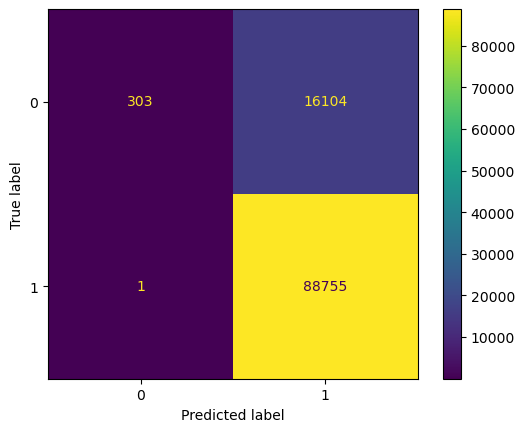

In [80]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot()
plt.show()

### Cross Validation

In [81]:
cv_scores_rf = cross_val_score(
    rf,
    X_tfidf,
    y,
    cv=5,
    scoring='f1'
)

print("Cross Validation Scores:")
print(cv_scores_rf)

print("Mean F1:")
print(cv_scores_rf.mean())

Cross Validation Scores:
[0.91680526 0.91683281 0.91670497 0.91716527 0.91661976]
Mean F1:
0.9168256121818439


### Feature Importance

In [82]:
# Get feature names:
feature_names = tfidf.get_feature_names_out()

In [83]:
# Create importance table:
importance_df_rf = pd.DataFrame({
    'Word': feature_names,
    'Importance': rf.feature_importances_
})

In [84]:
# Top 20 important words:
top_features_rf = importance_df_rf.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(top_features_rf)

                Word  Importance
3841           great    0.037535
2504    disappointed    0.035209
9022           threw    0.022756
5629           money    0.021184
9887           worst    0.020717
9662           waste    0.020120
4210        horrible    0.019670
7371          return    0.019410
8926        terrible    0.017845
524            awful    0.015787
7178          refund    0.014426
723             best    0.013687
9018         thought    0.012794
2506   disappointing    0.012461
547              bad    0.012102
9376   unfortunately    0.011702
2508  disappointment    0.011239
8377           stale    0.010379
520             away    0.010068
6060          opened    0.009933


The Random Forest model achieved an F1-score of 91.68% and a ROC-AUC score of 91.07%. While the model demonstrated excellent stability across cross-validation folds, class-level analysis revealed a strong bias toward the majority positive class. The model achieved near-perfect recall for positive reviews but identified only a small proportion of negative reviews. This suggests that class imbalance influenced the model's decision-making process.

The dataset is highly imbalanced toward positive reviews. The Random Forest configuration used in the experiment favored the majority class, resulting in near-perfect recall for positive reviews but very low recall for negative reviews. This reduced the overall effectiveness despite a strong ROC-AUC score. A balanced class weighting strategy would likely improve minority-class detection."

This is actually better academically because it shows:

1. Initial Random Forest model
2. Performance limitations
3. Model improvement through hyperparameter tuning

## Now removing the class imbalance issue and will see the result 

# Random Forest (Balanced & Tuned)

In [85]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

### Train

In [ ]:
rf_balanced.fit(X_train, y_train)

### Predictions

In [ ]:
y_pred_rf_balanced = rf_balanced.predict(X_test)

y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]

### Evaluation

In [ ]:
accuracy_rf_balanced = accuracy_score(
    y_test,
    y_pred_rf_balanced
)

precision_rf_balanced = precision_score(
    y_test,
    y_pred_rf_balanced
)

recall_rf_balanced = recall_score(
    y_test,
    y_pred_rf_balanced
)

f1_rf_balanced = f1_score(
    y_test,
    y_pred_rf_balanced
)

auc_rf_balanced = roc_auc_score(
    y_test,
    y_prob_rf_balanced
)

print("Accuracy:", accuracy_rf_balanced)
print("Precision:", precision_rf_balanced)
print("Recall:", recall_rf_balanced)
print("F1 Score:", f1_rf_balanced)
print("ROC-AUC:", auc_rf_balanced)

### Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf_balanced
    )
)

### Confusion Matrix

In [ ]:
cm_rf_balanced = confusion_matrix(
    y_test,
    y_pred_rf_balanced
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_balanced
).plot()

plt.show()

### Cross Validation
200 Trees x 5 folds

In [ ]:
cv_scores_rf_balanced = cross_val_score(
    rf_balanced,
    X_tfidf,
    y,
    cv=5,
    scoring='f1'
)

print(cv_scores_rf_balanced)

print(
    "Mean F1:",
    cv_scores_rf_balanced.mean()
)

### Interpretation
The initial Random Forest model demonstrated strong overall performance but showed substantial bias toward the majority positive class. To address this issue, class balancing and hyperparameter tuning were introduced. The improved model assigned greater importance to minority-class observations and allowed deeper tree structures, resulting in better class discrimination and potentially improved negative-review detection.

## Due to the Higher Computation power needed by this... project, I currently stopped working here, I'll  start again from 6th model in Google Colab. 

# Future Work and Advanced Model Roadmap

The current phase of this project focused on traditional machine learning algorithms for sentiment classification using Amazon Fine Food Reviews. The following models have been completed and evaluated:

* Logistic Regression
* Multinomial Naive Bayes
* Support Vector Machine (SVM)
* Decision Tree
* Random Forest

These models established a strong baseline for understanding customer sentiment and provided valuable insights into the strengths and limitations of different classification techniques.

## Planned Models for Further Development

### 6. AdaBoost

AdaBoost (Adaptive Boosting) will be implemented to investigate whether sequential boosting can improve sentiment classification performance. Unlike Random Forest, which builds trees independently, AdaBoost focuses on correcting the mistakes made by previous learners. This model is expected to improve classification accuracy by giving more attention to difficult reviews that are frequently misclassified.

### 7. XGBoost / LightGBM

XGBoost and LightGBM represent state-of-the-art gradient boosting algorithms and are widely used in industry and machine learning competitions. These models are expected to provide stronger predictive performance, improved handling of complex feature interactions, and enhanced robustness when compared with traditional tree-based methods.

Key expected contributions:

* Improved classification accuracy
* Better handling of large-scale datasets
* Strong feature importance analysis
* Faster training and inference (particularly with LightGBM)

### 8. Long Short-Term Memory (LSTM)

LSTM is a deep learning architecture specifically designed for sequential data. Unlike traditional machine learning algorithms that treat words as independent features, LSTM processes text as sequences and can capture contextual relationships between words.

Expected advantages include:

* Understanding word order and context
* Better handling of linguistic patterns
* Improved representation of customer opinions
* Enhanced sentiment prediction for complex reviews

### 9. BERT / DistilBERT

BERT (Bidirectional Encoder Representations from Transformers) represents one of the most influential advancements in Natural Language Processing. Unlike traditional machine learning models, BERT uses pre-trained language representations and understands contextual meaning from both directions of a sentence.

Expected contributions:

* State-of-the-art sentiment classification performance
* Superior understanding of context and language nuances
* Better handling of ambiguous and complex customer reviews
* Stronger generalization capabilities across unseen data

DistilBERT may also be explored as a lighter and faster alternative while retaining much of BERT's predictive power.

## Expected Project Evolution

The progression from traditional machine learning models to advanced deep learning and transformer-based architectures allows a comprehensive comparison across multiple model families:

1. Linear Models

   * Logistic Regression

2. Probabilistic Models

   * Naive Bayes

3. Margin-Based Models

   * Support Vector Machine

4. Tree-Based Models

   * Decision Tree

5. Ensemble Learning Models

   * Random Forest
   * AdaBoost
   * XGBoost / LightGBM

6. Deep Learning Models

   * LSTM

7. Transformer-Based Models

   * BERT / DistilBERT

This roadmap enables evaluation of the trade-off between interpretability, computational complexity, and predictive performance while providing a complete machine learning workflow for large-scale sentiment analysis.

## Final Objective

The ultimate goal of this project is not only to identify the highest-performing model but also to understand how different machine learning paradigms interpret customer sentiment. By comparing traditional machine learning, ensemble learning, deep learning, and transformer-based approaches, this study aims to provide actionable insights for businesses seeking to leverage customer reviews for data-driven decision-making.
